This section builds visualizations based off the data set collected in the sat_data section

In [318]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pygal as pygal
import leafmap as leafmap
import numpy as np

In [ ]:
# leafmap code generated by Copilot AI
file = 'buoy_locations.txt'
df = pd.read_csv(file, header = None)

df.columns = ['Buoy', 'Latitude', 'Longitude']

m = leafmap.Map(
    height=1000,
    width=1200,
    center=(0, 0),
    zoom=2,
)

m.add_circle_markers_from_xy(df, x='Longitude', y='Latitude')
m

Map(center=[0, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text'…

In [320]:
df_chl = pd.read_csv('buoy_chl_attached.csv')
df_chl.columns = ['buoy', 'date', 'lat', 'lon', 'chlor_a']

In [ ]:
# dictionary for loop to create a dictionary of buoys with their chlorophyll values for each date
# 
buoy_chl = {}
for index, row in df_chl.iterrows():
    buoy = row['buoy']
    date = row['date']
    #location = ([row['lat'], row['lon']])
    if buoy not in buoy_chl.keys():
        buoy_chl.update({buoy: []})
    if row['chlor_a'] >= 0:
        buoy_chl[buoy].append((date))

In [ ]:
dates = []
for key in buoy_chl.keys():
    dates.append(buoy_chl[key])



In [ ]:
len(dates)

In [331]:
# eventplot sorts based on size, so the order of the names 
sc = buoy_chl['Southern California']
cl = buoy_chl['Coastal Louisiana']
grg = buoy_chl['Grays Reef Georgia']
lp = buoy_chl['La Push']
bs = buoy_chl['SE Bering Sea']
sp = buoy_chl['South Pacific']
print(len(sc),
len(cl),
len(grg),
len(lp),
len(bs),
len(sp))
print(len(dates[0]),
      len(dates[1]),
      len(dates[2]),
      len(dates[3]),
      len(dates[4]),
      len(dates[5]),)

1469 1387 1627 1037 363 920
1469 1387 1627 1037 363 920


In [342]:
len(dates[0])

1469

Text(0.5, 1.0, 'Collection of pCO2 data for each buoy')

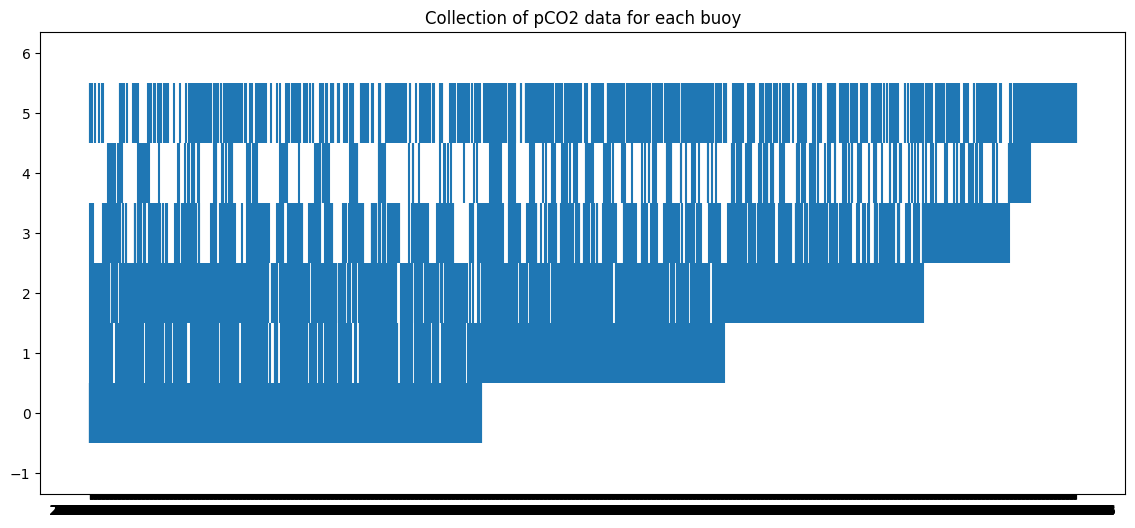

In [348]:
# creating an eventplot to show gaps in buoy data; ticklabels edited by Copilot
plt.figure(figsize=(14, 6))
offsets = [2,4,6,8,10,12]

plt.eventplot(dates)

names = buoy_chl.keys()
#plt.yticks(offsets, names)
plt.title('Collection of pCO2 data for each buoy')

In [ ]:
import matplotlib.dates as mdates

plot_dates = [mdates.date2num(pd.to_datetime(group)) for group in dates]

fig, ax = plt.subplots(figsize=(14, 5))
ax.eventplot(plot_dates, colors='tab:blue', lineoffsets=np.arange(len(plot_dates)), linelengths=0.8)

ax.set_yticks(np.arange(len(plot_dates)))
ax.set_yticklabels(list(buoy_chl.keys()))
ax.set_xlabel('Date')
ax.set_title('Event plot of buoy chlor_a sample dates')

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
plt.show()


IndexError: list index out of range